# 03 — Model Training (All 11 Activities)

Trains and compares three architectures optimized for embedded deployment:

1. **IDCNN** — Inception-style Dilated CNN with multi-scale temporal feature extraction  
2. **MS-CNN** — Multi-Scale CNN with parallel branch convolutions  
3. **TCN** — Temporal Convolutional Network with causal dilated convolutions  

All models are kept lightweight (<50K params) for XIAO nRF52840 deployment.

In [1]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers, callbacks
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.13.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Data

In [2]:
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
RESULTS_DIR = Path('../results')
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'preprocessing_info.pkl', 'rb') as f:
    info = pickle.load(f)

NUM_CLASSES = info['num_classes']
WINDOW_SIZE = info['window_size']
NUM_FEATURES = info['num_features']
ACTIVITIES = info['activities']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Classes: {NUM_CLASSES} | Window: {WINDOW_SIZE}x{NUM_FEATURES}')
print(f'Activities: {ACTIVITIES}')

Train: (29727, 128, 6) | Test: (1018, 128, 6)
Classes: 11 | Window: 128x6
Activities: ['ear_rubbing', 'forehead_rubbing', 'hair_pulling', 'hand_scratching', 'hand_tapping', 'knuckles_cracking', 'nail_biting', 'nape_rubbing', 'sitting', 'smoking', 'standing']


## 2. Compute Class Weights

In [3]:
class_weights_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}

print('Class weights:')
for i, act in enumerate(ACTIVITIES):
    count = np.sum(y_train == i)
    print(f'  {i:2d}: {act:25s} n={count:>5d}  weight={class_weights[i]:.3f}')

Class weights:
   0: ear_rubbing               n= 2778  weight=0.973
   1: forehead_rubbing          n= 2688  weight=1.005
   2: hair_pulling              n= 2718  weight=0.994
   3: hand_scratching           n= 2691  weight=1.004
   4: hand_tapping              n= 2685  weight=1.007
   5: knuckles_cracking         n= 2754  weight=0.981
   6: nail_biting               n= 2688  weight=1.005
   7: nape_rubbing              n= 2841  weight=0.951
   8: sitting                   n= 2568  weight=1.052
   9: smoking                   n= 2796  weight=0.967
  10: standing                  n= 2520  weight=1.072


## 3. Training Utilities

In [7]:
EPOCHS = 100
BATCH_SIZE = 64
LABEL_SMOOTHING = 0.1
L2_REG = 1e-4

print('Training configuration:')
print(f'  Epochs:          {EPOCHS}')
print(f'  Batch size:      {BATCH_SIZE}')
print(f'  Label smoothing: {LABEL_SMOOTHING}')
print(f'  L2 reg:          {L2_REG}')
print(f'  Val split:       15%')
print(f'  Early stopping:  patience=20, restore_best_weights=True')
print(f'  LR schedule:     ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6)')
print(f'  Optimizer:       Adam(lr=1e-3)')
print(f'  Loss:            SparseCategoricalCrossentropy')


def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
        ),
        callbacks.ModelCheckpoint(
            str(MODEL_DIR / f'best_{model_name}.h5'),
            monitor='val_loss', save_best_only=True, verbose=0
        ),
    ]


def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy'],
    )
    return model


def train_model(model, model_name):
    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'Parameters: {model.count_params():,}')
    print(f'{"="*60}')
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=get_callbacks(model_name),
        verbose=1,
    )
    
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')
    
    return history, test_loss, test_acc


def plot_results(history, model_name, test_acc):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{model_name} — Accuracy (test: {test_acc:.4f})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{model_name} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_training_history.png', dpi=150)
    plt.show()


def plot_confusion(model, model_name):
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITIES,
                yticklabels=ACTIVITIES, ax=ax1)
    ax1.set_title(f'{model_name} — Confusion Matrix (counts)')
    ax1.set_ylabel('True')
    ax1.set_xlabel('Predicted')
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES,
                yticklabels=ACTIVITIES, ax=ax2)
    ax2.set_title(f'{model_name} — Confusion Matrix (normalized)')
    ax2.set_ylabel('True')
    ax2.set_xlabel('Predicted')
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_confusion_matrix.png', dpi=150)
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names=ACTIVITIES, digits=4))

print(f'\nUtilities ready: get_callbacks, compile_model, train_model, plot_results, plot_confusion')

Training configuration:
  Epochs:          100
  Batch size:      64
  Label smoothing: 0.1
  L2 reg:          0.0001
  Val split:       15%
  Early stopping:  patience=20, restore_best_weights=True
  LR schedule:     ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6)
  Optimizer:       Adam(lr=1e-3)
  Loss:            SparseCategoricalCrossentropy

Utilities ready: get_callbacks, compile_model, train_model, plot_results, plot_confusion


---
## 4. Architecture 1: IDCNN (Inception Dilated CNN)

Parallel dilated convolutions with rates [1, 2, 4, 8] capture patterns at multiple temporal scales.  
Inception-style concatenation gives the model a rich multi-resolution view of the signal.

In [8]:
def inception_dilated_block(x, filters, dilation_rates, l2=L2_REG):
    """Inception block with parallel dilated convolutions."""
    branches = []
    for rate in dilation_rates:
        branch = layers.Conv1D(
            filters, kernel_size=3, dilation_rate=rate, padding='same',
            kernel_regularizer=regularizers.l2(l2),
            activation=None
        )(x)
        branch = layers.BatchNormalization()(branch)
        branch = layers.Activation('relu')(branch)
        branches.append(branch)
    
    # 1x1 convolution branch (captures point-wise features)
    branch_1x1 = layers.Conv1D(
        filters, kernel_size=1, padding='same',
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    branch_1x1 = layers.BatchNormalization()(branch_1x1)
    branch_1x1 = layers.Activation('relu')(branch_1x1)
    branches.append(branch_1x1)
    
    # Concatenate all branches
    merged = layers.Concatenate()(branches)
    
    # Bottleneck: reduce channel dimension
    out = layers.Conv1D(
        filters * 2, kernel_size=1, padding='same',
        kernel_regularizer=regularizers.l2(l2)
    )(merged)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)
    
    return out


def build_idcnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Initial feature extraction
    x = layers.Conv1D(32, kernel_size=7, padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.15)(x)
    
    # Inception-Dilated Block 1
    x = inception_dilated_block(x, filters=16, dilation_rates=[1, 2, 4, 8])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)
    
    # Inception-Dilated Block 2
    x = inception_dilated_block(x, filters=24, dilation_rates=[1, 2, 4])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Inception-Dilated Block 3
    x = inception_dilated_block(x, filters=32, dilation_rates=[1, 2])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    
    # Classifier
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs, name='IDCNN')


model_idcnn = build_idcnn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
model_idcnn = compile_model(model_idcnn)
model_idcnn.summary()

2026-04-29 09:14:31.450228: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-29 09:14:31.450427: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-29 09:14:31.450499: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-29 09:14:31.452094: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-29 09:14:31.453782: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "IDCNN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 6)]             0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 128, 32)              1376      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 128, 32)              128       ['conv1d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 128, 32)              0         ['batch_normalization[0][0


Training: idcnn
Parameters: 46,859
Epoch 1/100


2026-04-29 09:15:07.514250: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - ETA: 0s - loss: 1.4361 - accuracy: 0.5094

2026-04-29 09:15:44.065174: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - 42s 92ms/step - loss: 1.4361 - accuracy: 0.5094 - val_loss: 1.1583 - val_accuracy: 0.5978 - lr: 0.0010
Epoch 2/100
395/395 [==============================] - 36s 90ms/step - loss: 0.9928 - accuracy: 0.6674 - val_loss: 0.7973 - val_accuracy: 0.7422 - lr: 0.0010
Epoch 3/100
395/395 [==============================] - 36s 91ms/step - loss: 0.8642 - accuracy: 0.7136 - val_loss: 0.7749 - val_accuracy: 0.7332 - lr: 0.0010
Epoch 4/100
395/395 [==============================] - 36s 92ms/step - loss: 0.7891 - accuracy: 0.7450 - val_loss: 0.6705 - val_accuracy: 0.7816 - lr: 0.0010
Epoch 5/100
395/395 [==============================] - 36s 92ms/step - loss: 0.7437 - accuracy: 0.7562 - val_loss: 0.6311 - val_accuracy: 0.7960 - lr: 0.0010
Epoch 6/100
395/395 [==============================] - 37s 93ms/step - loss: 0.7036 - accuracy: 0.7728 - val_loss: 0.6555 - val_accuracy: 0.7816 - lr: 0.0010
Epoch 7/100
395/395 [==============================] - 41s 103ms

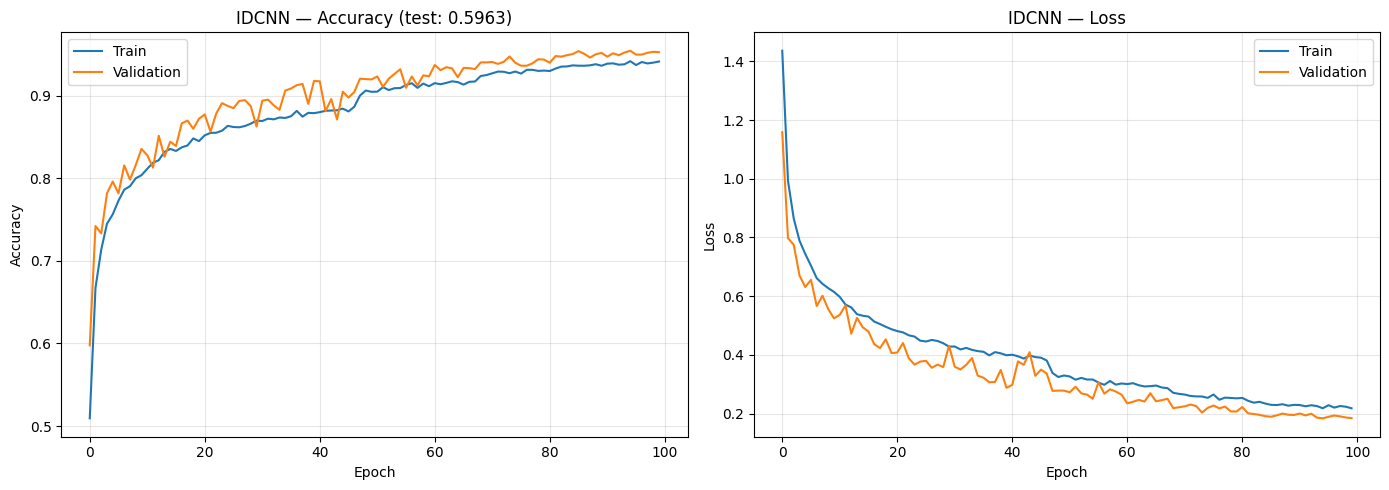

2026-04-29 10:18:09.509928: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


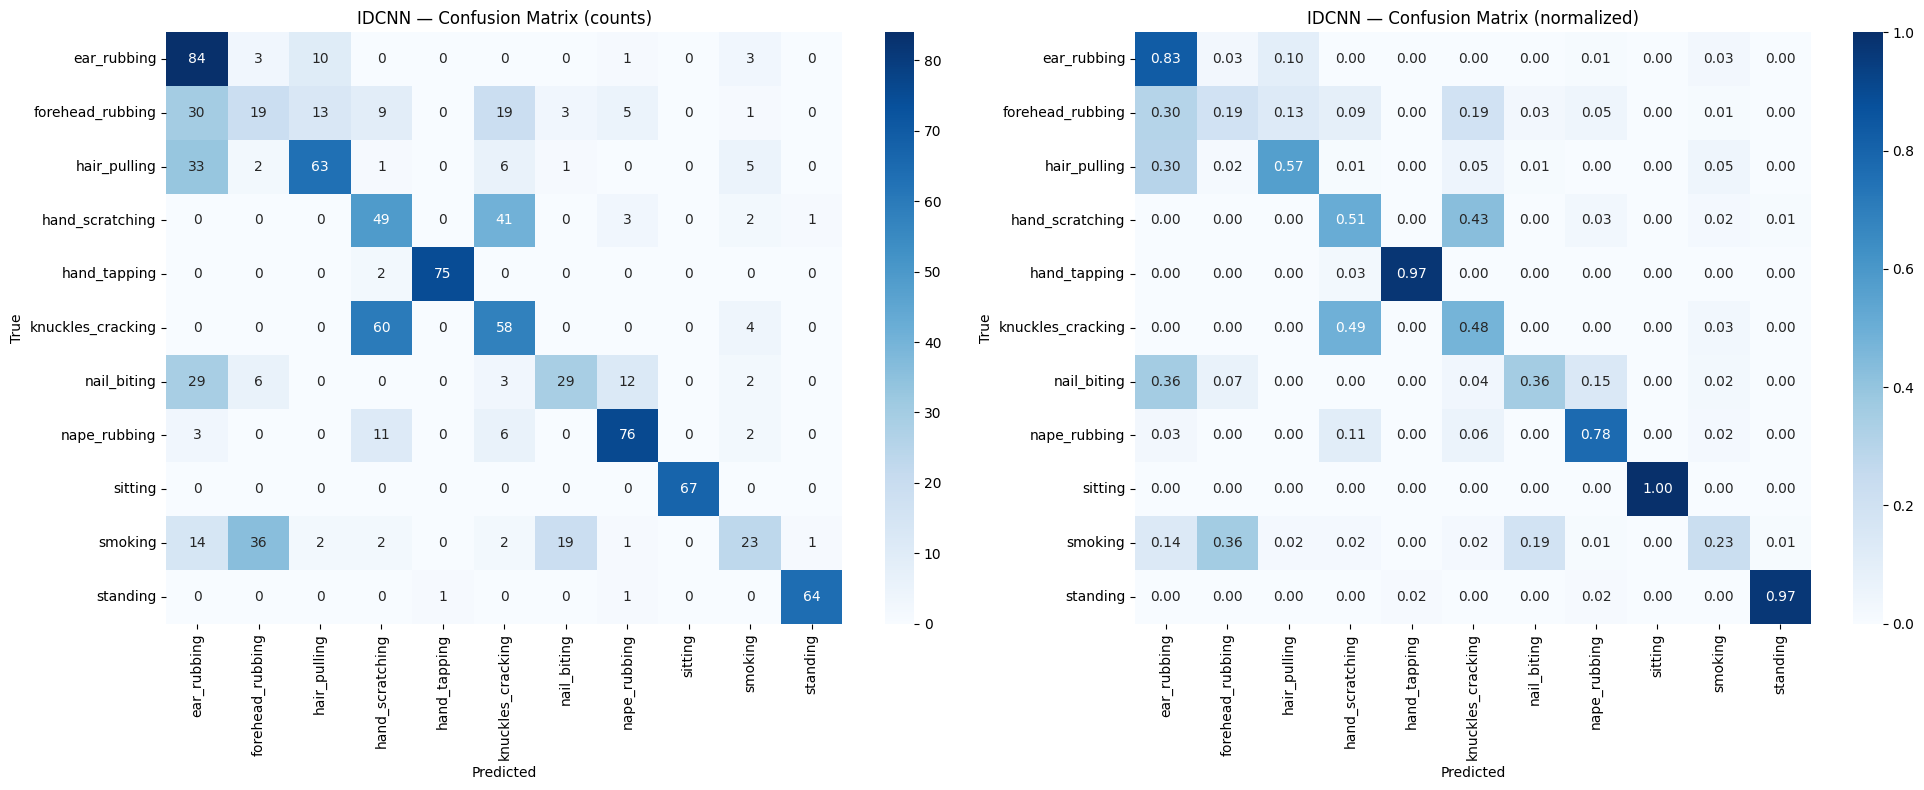

                   precision    recall  f1-score   support

      ear_rubbing     0.4352    0.8317    0.5714       101
 forehead_rubbing     0.2879    0.1919    0.2303        99
     hair_pulling     0.7159    0.5676    0.6332       111
  hand_scratching     0.3657    0.5104    0.4261        96
     hand_tapping     0.9868    0.9740    0.9804        77
knuckles_cracking     0.4296    0.4754    0.4514       122
      nail_biting     0.5577    0.3580    0.4361        81
     nape_rubbing     0.7677    0.7755    0.7716        98
          sitting     1.0000    1.0000    1.0000        67
          smoking     0.5476    0.2300    0.3239       100
         standing     0.9697    0.9697    0.9697        66

         accuracy                         0.5963      1018
        macro avg     0.6422    0.6258    0.6176      1018
     weighted avg     0.6106    0.5963    0.5860      1018



In [9]:
hist_idcnn, loss_idcnn, acc_idcnn = train_model(model_idcnn, 'idcnn')
plot_results(hist_idcnn, 'IDCNN', acc_idcnn)
plot_confusion(model_idcnn, 'IDCNN')

---
## 5. Architecture 2: Multi-Scale CNN

Parallel convolutions with different kernel sizes (3, 5, 7, 11) capture features at different scales.  
Residual connections help gradient flow.

In [12]:
def multiscale_block(x, filters, kernel_sizes, l2=L2_REG):
    """Parallel convolutions with different kernel sizes + residual."""
    branches = []
    for ks in kernel_sizes:
        branch = layers.Conv1D(
            filters, kernel_size=ks, padding='same',
            kernel_regularizer=regularizers.l2(l2)
        )(x)
        branch = layers.BatchNormalization()(branch)
        branch = layers.Activation('relu')(branch)
        branches.append(branch)
    
    merged = layers.Concatenate()(branches)
    
    # Bottleneck
    out = layers.Conv1D(
        filters * 2, kernel_size=1, padding='same',
        kernel_regularizer=regularizers.l2(l2)
    )(merged)
    out = layers.BatchNormalization()(out)
    
    # Residual connection if dimensions match
    if x.shape[-1] == filters * 2:
        out = layers.Add()([out, x])
    else:
        shortcut = layers.Conv1D(filters * 2, 1, padding='same')(x)
        shortcut = layers.BatchNormalization()(shortcut)
        out = layers.Add()([out, shortcut])
    
    out = layers.Activation('relu')(out)
    return out


def build_mscnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Initial projection
    x = layers.Conv1D(32, kernel_size=1, padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Multi-scale blocks
    x = multiscale_block(x, filters=16, kernel_sizes=[3, 5, 7, 11])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = multiscale_block(x, filters=16, kernel_sizes=[3, 5, 7])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    x = multiscale_block(x, filters=24, kernel_sizes=[3, 5])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    
    # Classifier
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs, name='MS_CNN')


model_mscnn = build_mscnn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
model_mscnn = compile_model(model_mscnn)
model_mscnn.summary()

Model: "MS_CNN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 128, 6)]             0         []                            
                                                                                                  
 conv1d_44 (Conv1D)          (None, 128, 32)              224       ['input_4[0][0]']             
                                                                                                  
 batch_normalization_44 (Ba  (None, 128, 32)              128       ['conv1d_44[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_42 (Activation)  (None, 128, 32)              0         ['batch_normalization_44[


Training: mscnn
Parameters: 40,363
Epoch 1/100


2026-04-29 10:20:52.538911: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - ETA: 0s - loss: 1.4971 - accuracy: 0.4762

2026-04-29 10:21:27.353763: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - 41s 92ms/step - loss: 1.4971 - accuracy: 0.4762 - val_loss: 1.0084 - val_accuracy: 0.6572 - lr: 0.0010
Epoch 2/100
395/395 [==============================] - 33s 83ms/step - loss: 0.9837 - accuracy: 0.6641 - val_loss: 0.7956 - val_accuracy: 0.7417 - lr: 0.0010
Epoch 3/100
395/395 [==============================] - 33s 83ms/step - loss: 0.8373 - accuracy: 0.7168 - val_loss: 0.6920 - val_accuracy: 0.7816 - lr: 0.0010
Epoch 4/100
395/395 [==============================] - 34s 86ms/step - loss: 0.7498 - accuracy: 0.7509 - val_loss: 0.6909 - val_accuracy: 0.7567 - lr: 0.0010
Epoch 5/100
395/395 [==============================] - 33s 83ms/step - loss: 0.7102 - accuracy: 0.7635 - val_loss: 0.5959 - val_accuracy: 0.8159 - lr: 0.0010
Epoch 6/100
395/395 [==============================] - 32s 82ms/step - loss: 0.6713 - accuracy: 0.7781 - val_loss: 0.5880 - val_accuracy: 0.8105 - lr: 0.0010
Epoch 7/100
395/395 [==============================] - 34s 86ms/

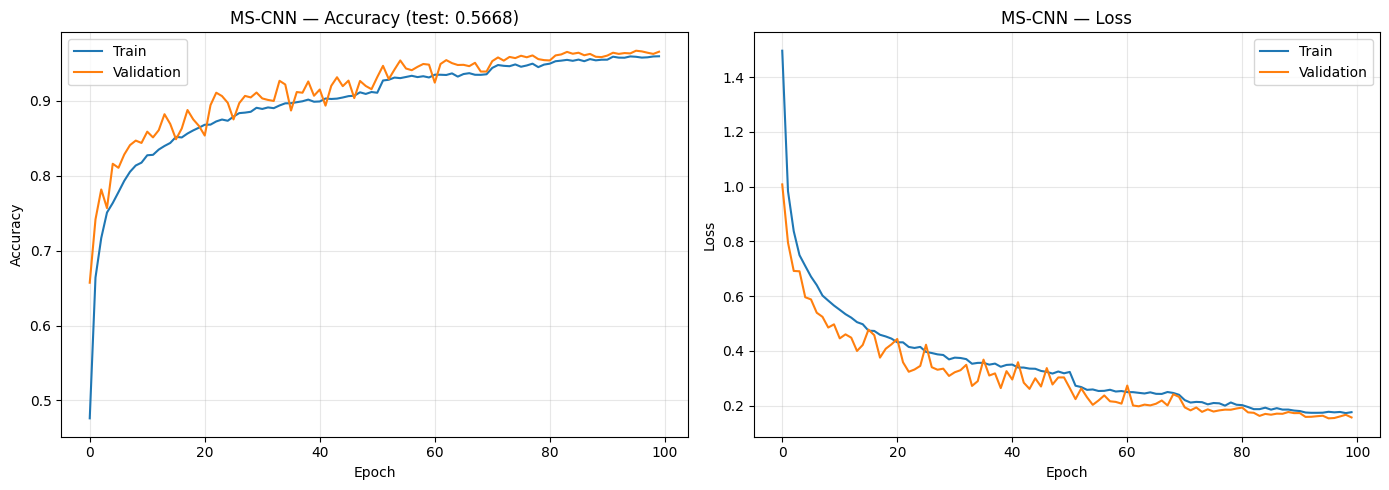

2026-04-29 11:27:11.026343: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


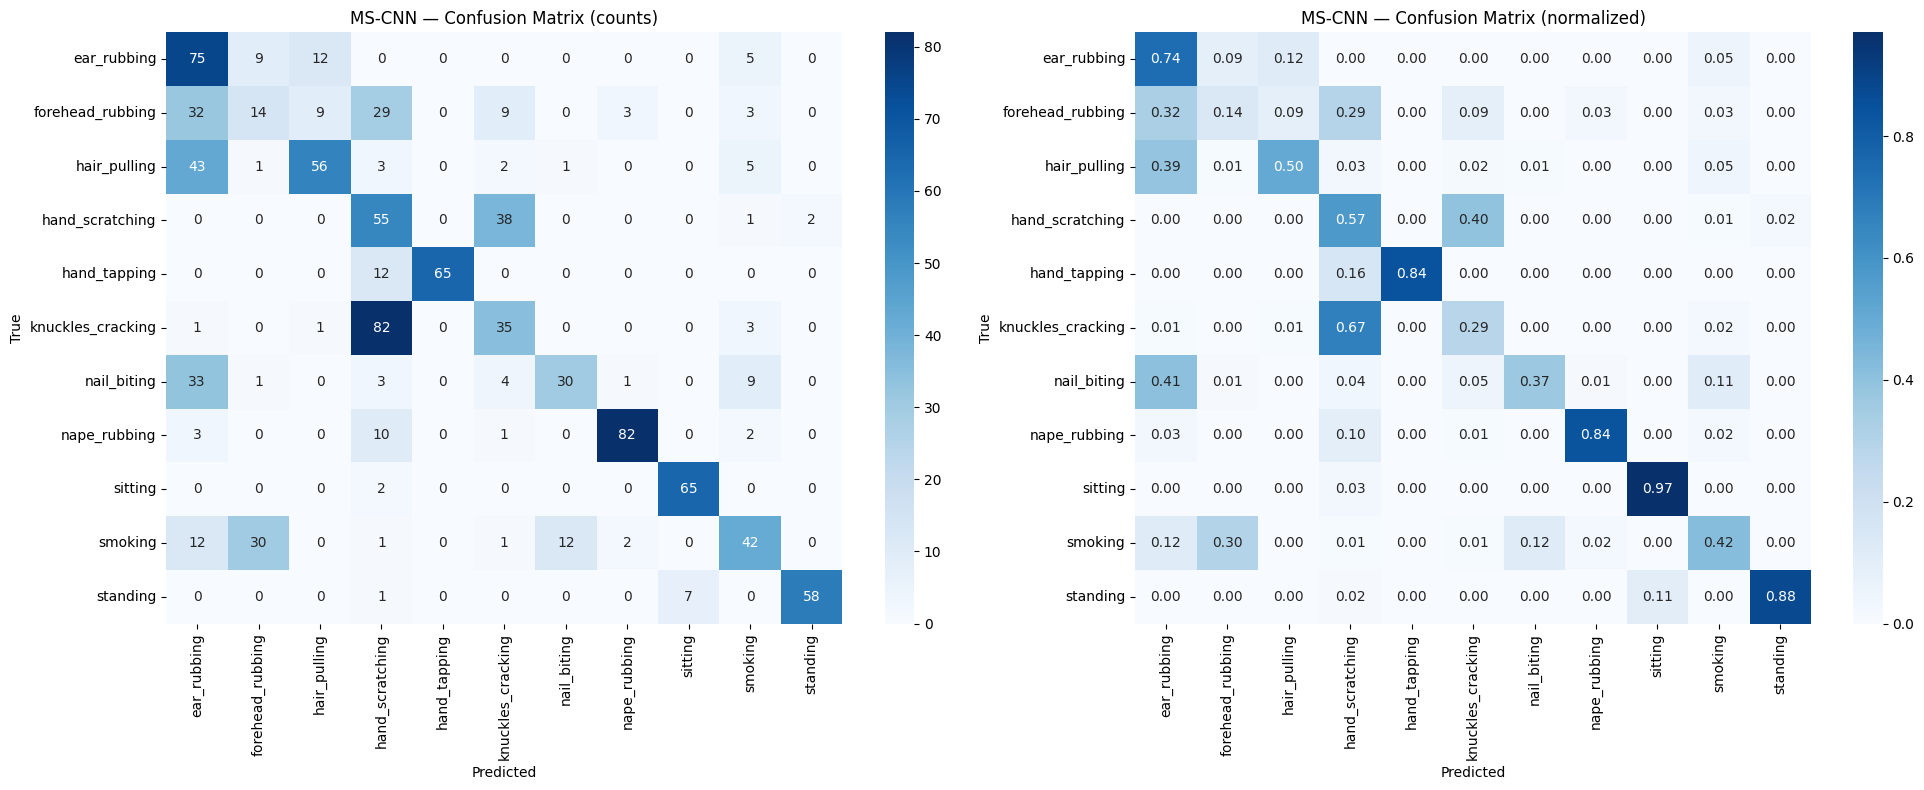

                   precision    recall  f1-score   support

      ear_rubbing     0.3769    0.7426    0.5000       101
 forehead_rubbing     0.2545    0.1414    0.1818        99
     hair_pulling     0.7179    0.5045    0.5926       111
  hand_scratching     0.2778    0.5729    0.3741        96
     hand_tapping     1.0000    0.8442    0.9155        77
knuckles_cracking     0.3889    0.2869    0.3302       122
      nail_biting     0.6977    0.3704    0.4839        81
     nape_rubbing     0.9318    0.8367    0.8817        98
          sitting     0.9028    0.9701    0.9353        67
          smoking     0.6000    0.4200    0.4941       100
         standing     0.9667    0.8788    0.9206        66

         accuracy                         0.5668      1018
        macro avg     0.6468    0.5971    0.6009      1018
     weighted avg     0.6151    0.5668    0.5692      1018



In [13]:
hist_mscnn, loss_mscnn, acc_mscnn = train_model(model_mscnn, 'mscnn')
plot_results(hist_mscnn, 'MS-CNN', acc_mscnn)
plot_confusion(model_mscnn, 'MS-CNN')

---
## 6. Architecture 3: TCN (Temporal Convolutional Network)

Stacked causal dilated convolutions with exponentially growing receptive field.  
Residual connections at each block.

In [14]:
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate, l2=L2_REG):
    """A single TCN residual block with 2 causal conv layers."""
    # First causal conv
    conv1 = layers.Conv1D(
        filters, kernel_size, dilation_rate=dilation_rate, padding='causal',
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    conv1 = layers.SpatialDropout1D(dropout_rate)(conv1)
    
    # Second causal conv
    conv2 = layers.Conv1D(
        filters, kernel_size, dilation_rate=dilation_rate, padding='causal',
        kernel_regularizer=regularizers.l2(l2)
    )(conv1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    conv2 = layers.SpatialDropout1D(dropout_rate)(conv2)
    
    # Residual connection
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding='same')(x)
    
    return layers.Add()([x, conv2])


def build_tcn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    x = inputs
    # Stacked dilated blocks: dilation = 1, 2, 4, 8, 16
    # Receptive field = 2 * kernel_size * sum(dilations) = 2 * 3 * 31 = 186 > 128
    for dilation_rate in [1, 2, 4, 8, 16]:
        x = tcn_residual_block(x, filters=32, kernel_size=3,
                               dilation_rate=dilation_rate, dropout_rate=0.15)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs, name='TCN')


model_tcn = build_tcn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
model_tcn = compile_model(model_tcn)
model_tcn.summary()

Model: "TCN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 128, 6)]             0         []                            
                                                                                                  
 conv1d_58 (Conv1D)          (None, 128, 32)              608       ['input_5[0][0]']             
                                                                                                  
 batch_normalization_58 (Ba  (None, 128, 32)              128       ['conv1d_58[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_55 (Activation)  (None, 128, 32)              0         ['batch_normalization_58[0][

In [ ]:
hist_tcn, loss_tcn, acc_tcn = train_model(model_tcn, 'tcn')
plot_results(hist_tcn, 'TCN', acc_tcn)
plot_confusion(model_tcn, 'TCN')


Training: tcn
Parameters: 32,875
Epoch 1/100


2026-04-29 11:30:39.738227: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - ETA: 0s - loss: 2.1688 - accuracy: 0.3435

2026-04-29 11:31:24.677266: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - 51s 121ms/step - loss: 2.1688 - accuracy: 0.3435 - val_loss: 1.3479 - val_accuracy: 0.5294 - lr: 0.0010
Epoch 2/100
395/395 [==============================] - 48s 122ms/step - loss: 1.4313 - accuracy: 0.4984 - val_loss: 1.1415 - val_accuracy: 0.6132 - lr: 0.0010
Epoch 3/100
395/395 [==============================] - 48s 121ms/step - loss: 1.2384 - accuracy: 0.5622 - val_loss: 1.0072 - val_accuracy: 0.6673 - lr: 0.0010
Epoch 4/100
 76/395 [====>.........................] - ETA: 34s - loss: 1.1541 - accuracy: 0.5919

---
## 7. Compare All Models

In [16]:
results = {
    'IDCNN': {'acc': acc_idcnn, 'loss': loss_idcnn, 'params': model_idcnn.count_params()},
    'MS-CNN': {'acc': acc_mscnn, 'loss': loss_mscnn, 'params': model_mscnn.count_params()},
}

print(f'{"Model":<12} {"Test Acc":>10} {"Test Loss":>10} {"Params":>10}')
print('-' * 45)
for name, r in results.items():
    print(f'{name:<12} {r["acc"]:>10.4f} {r["loss"]:>10.4f} {r["params"]:>10,}')

# Find best
best_name = max(results, key=lambda k: results[k]['acc'])
print(f'\nBest model: {best_name} ({results[best_name]["acc"]:.4f} accuracy)')

Model          Test Acc  Test Loss     Params
---------------------------------------------
IDCNN            0.5963     1.6434     46,859
MS-CNN           0.5668     2.2951     40,363

Best model: IDCNN (0.5963 accuracy)


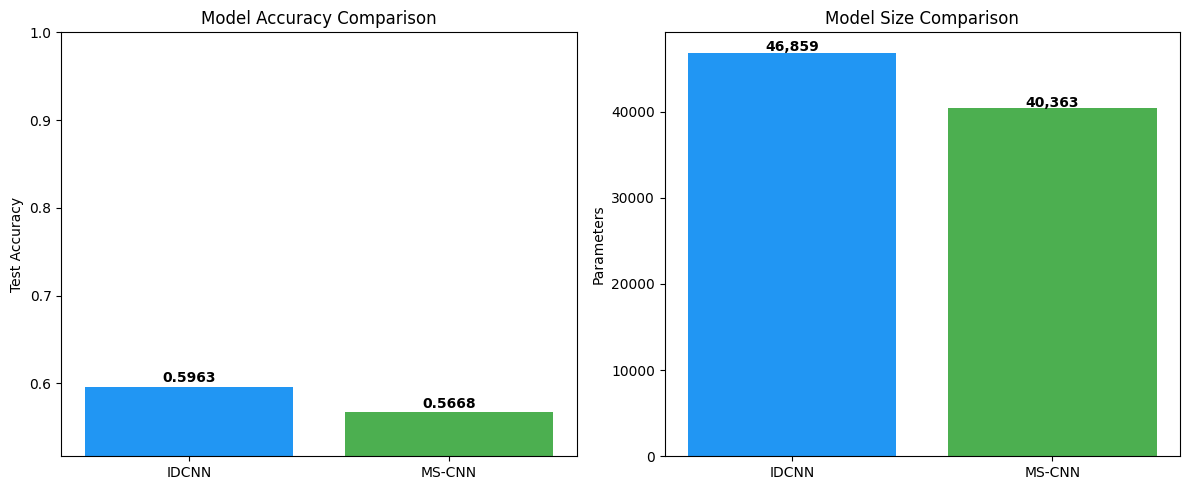

In [17]:
# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

names = list(results.keys())
accs = [results[n]['acc'] for n in names]
params = [results[n]['params'] for n in names]

colors = ['#2196F3', '#4CAF50']
ax1.bar(names, accs, color=colors)
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim(min(accs) - 0.05, 1.0)
for i, v in enumerate(accs):
    ax1.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

ax2.bar(names, params, color=colors)
ax2.set_ylabel('Parameters')
ax2.set_title('Model Size Comparison')
for i, v in enumerate(params):
    ax2.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150)
plt.show()

## 8. Save Best Model

In [18]:
best_models = {'IDCNN': model_idcnn, 'MS-CNN': model_mscnn}
best_model = best_models[best_name]

# Save best model
best_model.save(MODEL_DIR / 'best_model_v2.h5')

# Save all models
model_idcnn.save(MODEL_DIR / 'model_idcnn_v2.h5')
model_mscnn.save(MODEL_DIR / 'model_mscnn_v2.h5')

# Save training info
training_info = {
    'best_model': best_name,
    'results': results,
    'num_classes': NUM_CLASSES,
    'activities': ACTIVITIES,
    'window_size': WINDOW_SIZE,
    'num_features': NUM_FEATURES,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'label_smoothing': LABEL_SMOOTHING,
    'l2_reg': L2_REG,
    'class_weights': class_weights,
    'histories': {
        'IDCNN': hist_idcnn.history,
        'MS-CNN': hist_mscnn.history,
    },
}

with open(MODEL_DIR / 'training_info_v2.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f'Best model ({best_name}) saved to models/best_model_v2.h5')
print(f'All models and training info saved.')

Best model (IDCNN) saved to models/best_model_v2.h5
All models and training info saved.
